# Content-based recommendations

## Introduction

Imagine you have been using a film platform for a while. You have rated a few films. Some you loved, some not so much.

![A viewer's history of rated films, and the question: what should I watch next?](images/platform_history.svg)

This time, the platform knows two things:
- **your ratings**: which films you liked, and which ones you did not,
- **the films themselves**: what each film is about, for example its genres.

The idea of a **content-based recommender** fits in one sentence: *you liked horror films? Here are more horror films.* We look at the content of the films you liked, and recommend films with a similar content.

## Example scenario

Let's make it concrete with real data.

We use **MovieLens 100K**, a classic dataset from the [GroupLens research group](https://grouplens.org/datasets/movielens/100k/): 943 users gave 100,000 ratings, from 1 to 5, to 1,682 films.

I wrote a small `movielens` module that downloads the dataset and reads the files. We treat it as a black box. First, the films:

In [1]:
from recommendationsystems.movielens import load_movies

genre_names, titles, genres = load_movies()

print(f"{len(titles)} films, {len(genre_names)} genres")
print(genre_names)

1682 films, 19 genres
['unknown', 'Action', 'Adventure', 'Animation', "Children's", 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']


Each film has a number (its position in the list), a title, and its genres. Let's look at the first one:

In [2]:
toy_story = 0

print(titles[toy_story])
print(genres[toy_story])

Toy Story (1995)
[0. 0. 0. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


The genres of a film are a row of 0s and 1s, with one cell per genre. A 1 means that the film has this genre. Toy Story is an animated film, for children, and a comedy:

![Toy Story's genres become a row of 19 cells, with a 1 for Animation, Children's and Comedy.](images/film_as_vector.svg)

That is all a film is for our recommender: a row of numbers. We call it a **vector**.

Now, the ratings. Each row is one rating: a user, a film, and a rating from 1 to 5. The rows are sorted by time.

In [3]:
from recommendationsystems.movielens import load_ratings

ratings = load_ratings()
print(ratings[:5])

[[259 254   4]
 [259 285   4]
 [259 297   4]
 [259 184   4]
 [259 172   4]]


Let's meet the user we will follow in this chapter, user 366. Here are the films they rated 4 or 5, that is, the films they **liked**:

In [4]:
fan = 366
fan_ratings = ratings[ratings[:, 0] == fan]

for movie in fan_ratings[fan_ratings[:, 2] >= 4, 1][:10]:
    print(titles[movie])

Tales from the Crypt Presents: Bordello of Blood (1996)
Scream (1996)
Braindead (1992)
Psycho (1960)
Pulp Fiction (1994)
Bad Taste (1987)
Silence of the Lambs, The (1991)
Birds, The (1963)
Army of Darkness (1993)
Evil Dead II (1987)


No need to be an expert: user 366 loves horror films. Keep them in mind, we will check what each recommender suggests to them.

### How do we know if a recommender is good?

We cannot ask the real users what they think of our recommendations. So we use a little trick: we **hide the last 10 ratings** of each user, as if they had not happened yet.

The recommender only sees the rest, the user's **history**, and suggests 10 films. Then we reveal the hidden ratings. If at least one of the 10 suggested films was liked later (rated 4 or 5), it is a **hit**!

In [5]:
import numpy as np
from recommendationsystems.movielens import MovieId, UserId

history = {}  # key: user, value: array of (film, rating) the recommender can see
liked_later = {}  # key: user, value: set of hidden films the user liked
for user in np.unique(ratings[:, 0]):
    user_ratings = ratings[ratings[:, 0] == user]
    history[user] = user_ratings[:-10, 1:]
    liked_later[user] = {movie for movie, rating in user_ratings[-10:, 1:] if rating >= 4}

def liked(user: UserId) -> np.ndarray:
    return history[user][history[user][:, 1] >= 4, 0]

All our recommenders will work the same way: they give **a score to every film**, and we keep the 10 films with the best score. We only skip the films the user has already seen, of course.

In [6]:
def top_10(scores: np.ndarray, user: UserId) -> list[MovieId]:
    """Return the 10 best-scored films that the user has not seen yet."""
    seen = set(history[user][:, 0])
    best_first = np.argsort(-scores, kind="stable")  # all films, best score first
    return [int(movie) for movie in best_first if movie not in seen][:10]

We evaluate each recommender on the same users: those who liked at least one film before and after the cut. The score is the **hit rate**: the share of users for whom we got at least one hit.

In [7]:
from collections.abc import Callable

test_users = [user for user in history if liked_later[user] and len(liked(user))]

def evaluate(reco: Callable[[UserId], list[MovieId]]) -> float:
    hits = [bool(set(reco(user)) & liked_later[user]) for user in test_users]
    return sum(hits) / len(hits)

As a reference point, here is a recommender that gives a random score to every film:

In [ ]:
rng = np.random.default_rng(21)

def random_reco(user: UserId) -> list[MovieId]:
    random_ratings = rng.random(len(titles))
    return top_10(random_ratings, user)

print(f"Random: {evaluate(random_reco):.3f}")

Random: 0.034


With 1,682 films to choose from, picking 10 at random rarely hits. Any useful recommender should beat that.

## Popular films: one list for everyone

### a. Let's make a first guess

Before using any content, let's start with the simplest idea: forget about the user, and recommend what everybody likes.

The score of a film is simply its number of **likes**: how many users rated it 4 or 5.

In [9]:
likes = np.bincount(np.concatenate([liked(user) for user in history]), minlength=len(titles))

def popular_reco(user: UserId) -> list[MovieId]:
    return top_10(likes, user)

for movie in popular_reco(fan):
    print(titles[movie])

Star Wars (1977)
Fargo (1996)
Return of the Jedi (1983)
Raiders of the Lost Ark (1981)
Contact (1997)
Godfather, The (1972)
Toy Story (1995)
Empire Strikes Back, The (1980)
English Patient, The (1996)
Fugitive, The (1993)


### b. How does this recommender perform?

In [10]:
print(f"Popular: {evaluate(popular_reco):.3f}")

Popular: 0.346


That's a huge jump! Popular films are popular for a reason: many people like them.

But look at the list again. Star Wars, Fargo, Toy Story... for our horror fan? Everybody gets the same list. The recommender ignores the one thing we know about this user: their taste.

## Similar films: cosine similarity

### a. When are two films similar?

We know the genres of every film. Two films are similar if they share their genres. Toy Story and Young Frankenstein are both comedies, so they are somewhat similar. Toy Story and Psycho have nothing in common.

To measure this, we see each vector as an **arrow**. Two films with the same genres point in the same direction. Two films with no genre in common point in completely different directions. We measure the angle between the two arrows with the **cosine similarity**:

![Keeping only Comedy and Horror, each film is an arrow; the smaller the angle, the higher the similarity.](images/cosine_similarity.svg)

- same direction: the similarity is 1,
- nothing in common: the similarity is 0,
- in between: a value in between.

The formula is short. For two vectors $a$ and $b$, we divide their dot product by their lengths:

$$
\text{similarity}(a, b) = \frac{a \cdot b}{\|a\| \, \|b\|}
$$

In code, we compare one vector with all the films at once:

In [11]:
def cosine_similarity(vector: np.ndarray, matrix: np.ndarray) -> np.ndarray:
    lengths = np.linalg.norm(matrix, axis=1) * np.linalg.norm(vector)
    return matrix @ vector / lengths

Let's find the films most similar to Toy Story:

In [12]:
similarities = cosine_similarity(genres[toy_story], genres)

for movie in np.argsort(-similarities, kind="stable")[1:6]:  # skip Toy Story itself
    print(f"{similarities[movie]:.2f}  {titles[movie]}")

1.00  Aladdin and the King of Thieves (1996)
0.87  Aladdin (1992)
0.87  Goofy Movie, A (1995)
0.82  Santa Clause, The (1994)
0.82  Home Alone (1990)


Not bad at all: animated films and children's comedies. This is already a "more like this" button.

### b. From one film to one user: the profile

To recommend to a user, we need to compare the films with the **user**, not with one film. So let's turn the user into a vector too!

The idea: the **profile** of a user is the average of the vectors of the films they liked.

![Three liked films, simplified to four genres, are averaged into a user profile.](images/user_profile.svg)

Each cell of the profile tells how much the user likes a genre. Let's build the profile of our horror fan:

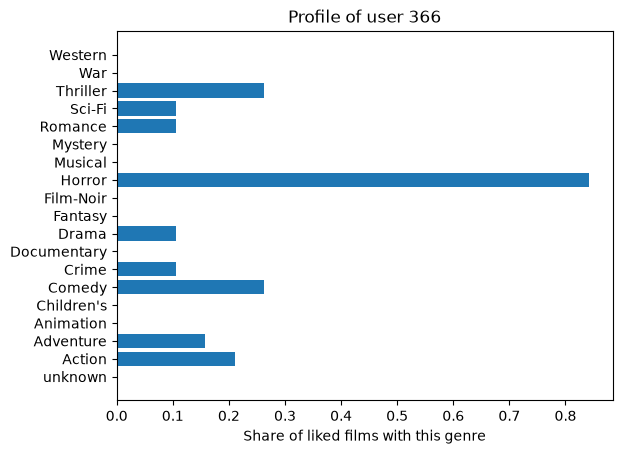

In [13]:
import matplotlib.pyplot as plt

def profile(user: UserId) -> np.ndarray:
    return genres[liked(user)].mean(axis=0)

plt.barh(genre_names, profile(fan))
plt.xlabel("Share of liked films with this genre")
plt.title(f"Profile of user {fan}")
plt.show()

Horror stands out, as expected.

### c. Let's recommend from the profile

The score of a film is now its similarity with the profile of the user:

In [14]:
def content_reco(user: UserId) -> list[MovieId]:
    return top_10(cosine_similarity(profile(user), genres), user)

for movie in content_reco(fan):
    print(titles[movie])

Shining, The (1980)
Prophecy II, The (1998)
Tales From the Crypt Presents: Demon Knight (1995)
Children of the Corn: The Gathering (1996)
Amityville 1992: It's About Time (1992)
Amityville 3-D (1983)
Amityville: A New Generation (1993)
Amityville II: The Possession (1982)
Amityville Horror, The (1979)
Amityville Curse, The (1990)


Personal, for sure. Only horror films! But six Amityville films in a row?

### d. How does this recommender perform?

In [15]:
print(f"Content-based: {evaluate(content_reco):.3f}")

Content-based: 0.118


Ouch. Much better than random, but much worse than popular films. What happened?

The genres tell us **what** a film is, not whether it is **good**. For our recommender, *Amityville 3-D* and *The Shining* look exactly the same: two horror films. Hundreds of films share the same genres, and nothing helps the recommender tell a classic from a forgotten sequel.

The two recommenders fail in opposite ways:
- the popular recommender knows which films are good, but not for whom,
- the content-based recommender knows what you like, but not which films are good.

Why not use both?

## Best of both worlds: similar and popular

### a. Let's combine the two scores

We want films that are close to the user's taste **and** liked by many people. A simple way is to multiply the two scores:

`score = similarity with the profile × number of likes`

A film gets a high score only if both numbers are high. A forgotten Amityville sequel with a perfect similarity but almost no likes stays at the bottom.

In [16]:
def hybrid_reco(user: UserId) -> list[MovieId]:
    return top_10(cosine_similarity(profile(user), genres) * likes, user)

for movie in hybrid_reco(fan):
    print(titles[movie])

Alien (1979)
Star Wars (1977)
Shining, The (1980)
Fargo (1996)
Young Frankenstein (1974)
Return of the Jedi (1983)
Princess Bride, The (1987)
Raiders of the Lost Ark (1981)
Fugitive, The (1993)
Rock, The (1996)


Alien, The Shining, Young Frankenstein: much better for our horror fan. Some very popular films like Star Wars are still there: when a film has hundreds of likes, it only needs a small similarity to stay in the list.

### b. How does this recommender perform?

In [17]:
print(f"Similar × popular: {evaluate(hybrid_reco):.3f}")

Similar × popular: 0.364


We beat the popular films! The gain is small, but it is a real one: the list is now built for each user.

## The superpower of content: brand-new films

There is one more thing the content can do, and it matters a lot on a real platform.

Imagine a new horror comedy is released today. Nobody has rated it yet, so it has zero likes. The popular recommender will never show it, and neither will our "similar × popular" recommender: anything times zero is zero.

But its genres are known on day one. So the content-based recommender can already tell who might like it:

In [18]:
new_film = np.zeros(len(genre_names))
new_film[[genre_names.index("Comedy"), genre_names.index("Horror")]] = 1

similarity = cosine_similarity(new_film, profile(fan)[None])[0]
print(f"Similarity with the profile of user {fan}: {similarity:.2f}")

Similarity with the profile of user 366: 0.80


A high similarity, before any rating! This is the **cold start** problem: recommending something that nobody has rated yet. Here, the content handles a new film. For a new user, their context can do the same: their country, their device (chapter 1). That is why real systems usually mix both kinds of scores.

## In summary

| Recommender | Uses | Hit rate |
|---|---|---|
| Random | nothing | 0.034 |
| Popular | everybody's likes | 0.346 |
| Content-based | the user's liked genres | 0.118 |
| Similar × popular | both | 0.364 |

A content-based recommender describes each film with features, like its genres, and each user with a profile: the average of the films they liked. The cosine similarity between the profile and a film gives a score, and we recommend the films with the best scores.

Alone, it knows what a user likes, but not which films are good. Combined with popularity, it beats the popular films. And it has a superpower: it can recommend a film that nobody has rated yet.

But notice how we used the other users: only to count likes. They can tell us much more. If users who liked the same films as you also loved a film you have not seen, it is probably a good recommendation for you, whatever its genres. That is the idea of **collaborative filtering**, our next chapter.